(sup_class_ex:data)=

## Data Exploring and Processing

Here we'll do two essential things. 

1. Process the data.
2. Analyze the data.

Processing will involve importing, cleaning, and sorting raw data; preparing it to be analyzed. Exploring the data builds an understanding of it and the problem you're trying to solve, equipping you to develop a machine-learning application.       

Before doing anything with raw data, you must import it.

In [1]:
# We'll import libraries as needed, but when submitting, 
# it's best to have them all at the top.
import pandas as pd

# Load this well-worn dataset:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/iris.csv"
df = pd.read_csv(url) #read CSV into Python as a DataFrame
df # displays the DataFrame



,5.1,3.5,1.4,0.2,Iris-setosa
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa
...,...,...,...,...,...
144,6.7,3.0,5.2,2.3,Iris-virginica
145,6.3,2.5,5.0,1.9,Iris-virginica
146,6.5,3.0,5.2,2.0,Iris-virginica
147,6.2,3.4,5.4,2.3,Iris-virginica


*Oops.** The first row of data has been set as headers. Some data sets have headers already -this one doesn't. How do we fix that? Google ["how to python add headers to dataframe"](https://www.google.com/search?q=how+to+python+add+headers+to+dataframe&rlz=1C1GCEA_enUS995US997&ei=7TuSY7TmGsyJggfflr3YCg&ved=0ahUKEwj0kK_X4er7AhXMhOAKHV9LD6sQ4dUDCA8&uact=5&oq=how+to+python+add+headers+to+dataframe&gs_lcp=Cgxnd3Mtd2l6LXNlcnAQAzIGCAAQCBAeMgUIABCGAzIFCAAQhgMyBQgAEIYDMgUIABCGAzoKCAAQRxDWBBCwAzoHCAAQgAQQDToICAAQCBAeEA06CAgAEAgQBxAeSgQIQRgASgQIRhgAULgCWMkIYMEfaAFwAXgAgAFPiAH1A5IBATeYAQCgAQHIAQjAAQE&sclient=gws-wiz-serp). You'll need to learn a lot of micro-skills -pick them up when needed. Reading up on the data set, [Iris flower data set](https://en.wikipedia.org/wiki/Iris_flower_data_set), we name the columns:

In [2]:
column_names = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'type']
df = pd.read_csv(url, names = column_names) #read CSV into Python as a DataFrame
df # displays the DataFrame

,sepal-length,sepal-width,petal-length,petal-width,type
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


```{alarm}
**Your data doesn't look like this?** Different data might need different code. Don't *paste and pray*; adjust what you do according to what you have and need.    
```

Supervised methods use "answers" in the data to supervise the model. Does our data contain the "answers"? If we want to predict the Iris 'type,' then yes. It's the only categorical feature, so we'll go with it. However, a supervised method could predict *any* of the features, e.g., 'sepal-length.' A supervised method can't predict what it doesn't have, say, plant height or petal color. 

```{margin}
What? That's it for data processing? We didn't do much becasue the data didn't need much. Like a lot of data out there, it was (mostly) ready to go. No minimal processing is required. The project's needs determine the required data processing, i.e., if it works, you've done enough. See [Data Requirements](task2c:data_requirements). 
```

That's all the processing needed for now. 

(sup_class_ex:descriptive_methods_and_visualizations)=

### Descriptive Methods and Visualizations

Let's explore the data. A good starting question: how many different Iris categories do we have?

In [3]:
num_types = df.groupby(by='type').size();
display(num_types); 

type
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
dtype: int64

(sup_class_ex:descriptive:visuals)=
Let's *visualize* that with a **bar plot**.
<!-- NOTE: Alt text for Python generated images added using Jupyter notebook cell's "img alt": "A bar plot is displayed. The x-axis are the type categories, and the y-axis is the number in the categories. Three bars Iris-setosa (red), Iris-versicolor (blue), and Iris-virginica (green) are each equal to 50",
     "output_type": "display_data"-->

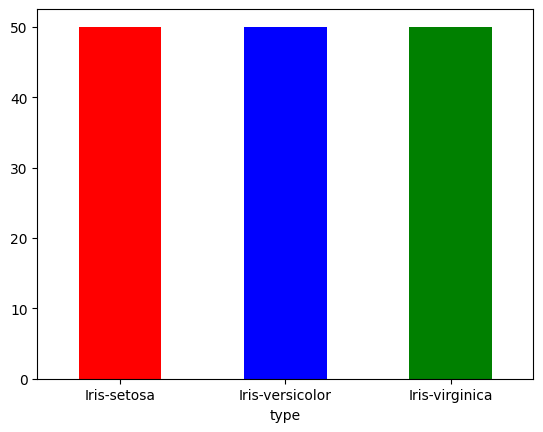

In [4]:
#Using Pandas plot.bar 
plot = num_types.plot.bar(color=['red','blue','green'],rot=0)

In [5]:
import matplotlib.pyplot as plt 
from IPython.display import display, HTML
import os

#This code helps support alt text for student accessibility.
#This section and uses of 'plot_with_alt' are intended only for publishing to the webpage.
#Including alt text is good practice but not required for Task 2.    

# A function to support adding alt text to Python-generated images.
# Pandas, matplotlib, and others don't yet natively support alt ext. 
# The workflow is as follows: 
# 1. Create images
# 2. Recreate the same images using the function adding alt text.
# 3. Add metadata tags to 'remove-output' from (1) and input from (2)
   
def plot_with_alt_text(alt_text =''):
     i = 0 #filename counter
     outputName = 'output_plot'+str(i)+'.png'
     match = True
     while(match == True):
          if os.path.isfile(outputName):
               i = i+1
               outputName = 'output_plot'+str(i)+'.png'
          else: match = False
     plt.savefig(outputName)
     plt.savefig('../../_build/html/task2_c/example_sup_class/'+outputName)
     display(HTML(f'<img src="{outputName}" alt="{alt_text}">'))
     plt.close()
          
plot = num_types.plot.bar(color=['red','blue','green'],rot=0)
plot_with_alt_text('A bar plot showing the distribution of the three flower types in the data.' \
     + 'Each has a height of 50. Iris-setosa = red, Iris-versicolor = blue, and Iris-virginica = green.')


```{margin}
Want to do something similar but different? Go to the [libary's docs](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.bar.html). You'll see many libraries and functions each with lots of options. Don't just copy, paste, and pray. Read the docs and understand the parameters.
```

Three evenly distributed categories. What about the distribution of the petal widths? As with most things in nature, we might expect it to be somewhat normal.

(sup_class_ex:descriptive:visuals:histograms)=

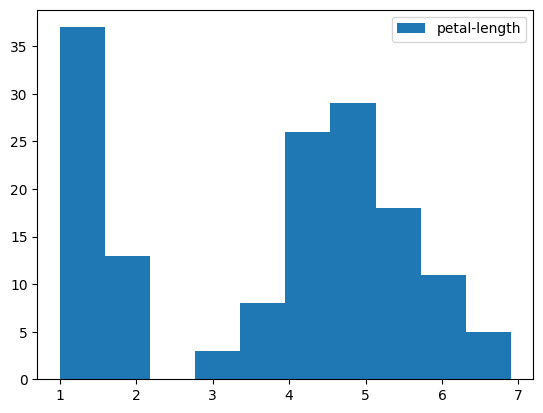

In [6]:
hist_petal_lengths = df['petal-length'].hist(grid = False,bins=10, legend = True)

In [7]:
hist_petal_lengths = df['petal-length'].hist(grid = False,bins=10,legend = True)
plot_with_alt_text('A histogram showing the distribution of petal-length over 10 bins ranging 0-7 (x-axis).' \
                   + 'The y-axis is the number in each bin ranging 0-40.' \
                   + 'Two distinct groupings are shown. One grouping has 2 bins with an x-range of approximately = [1, 2.2] and a y-range approximately = [0, 38].' \
                   + 'The second grouping appears normally distributed. It has 7 bins with an x-range of approximately = [2.8, 6.8] and a y-range of approximately = [0, 28].')

Not so normal. However, we are looking at the petal lengths of all three types. So let's look at a single type.

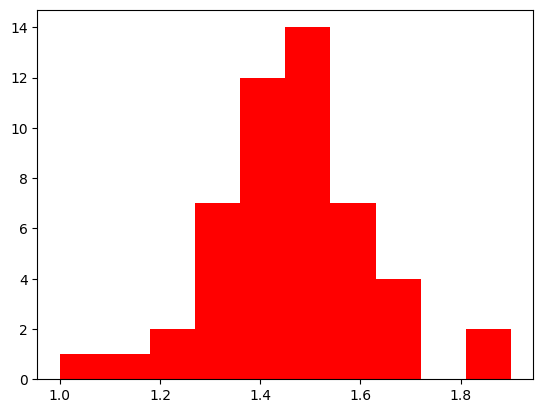

In [8]:
df_typeA = df[df['type'] == 'Iris-setosa']
df_typeA['petal-length'].hist(grid = False, color = 'red');

In [9]:
df_typeA['petal-length'].hist(grid = False, color = 'red');
plot_with_alt_text('A histogram showing the distribution of petal-length for the Iris-setosa typer. There are 10 bins ranging 1-2 (x-axis).' \
                   + 'The y-axis is the number in each bin ranging 0-14.' \
                   + 'There is one grouping appearing normally distributed an x-range of approximately = [1.0, 1.95] and a y-range of approximately = [0, 14].')

Evaluators don't assess aesthetics, but Pandas' visualizations are limited compared to others. Below we get a much better picture of what's going on, and we clearly see the three different types.

A **histogram** to visualize distributions:

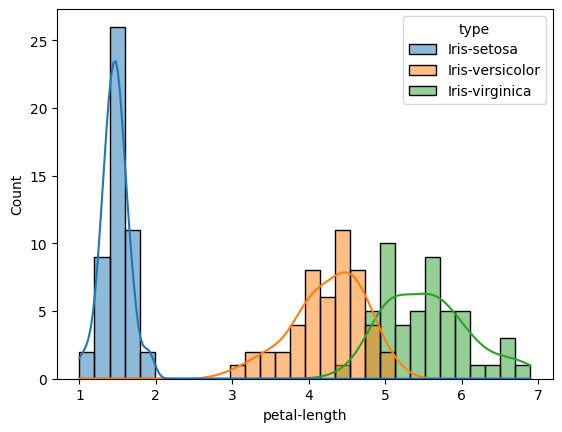

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df,x='petal-length', hue='type', kde=True, bins =30);

In [11]:
sns.histplot(df,x='petal-length', hue='type', kde=True, bins = 30)
plot_with_alt_text('A histogram showing the distribution of petal-length over 30 bins ranging 0-7 (x-axis).' \
                   + 'The y-axis is the number in each bin ranging 0-30.' \
                   + 'The bins are color according to their type as follows:'\
                   + 'Blue = Iris-setosa, Orange = Iris-versicolor, Green = Iris-vriginica.'\
                   + "Each type has it's own similarly colored kernel density estimate to smoothly approximate the types distribution."\
                   + "The colors each appear normally distributed as follows:"\
                   + "Blue has an approximate median of 1.5 with .95 of data between 1 and 2."\
                   + "Orange has an approximate median of 4.33 with .95 of data between 3 and 5.25"\
                   + "Green has an approximate median of 5.5 with .95 of data between 4.5 and 7.")

A **scatterplot** to visualize popssible correlations: 

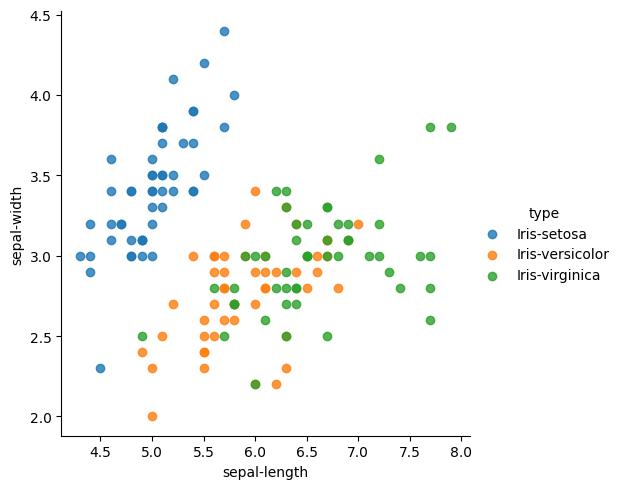

In [12]:
#https://seaborn.pydata.org/generated/seaborn.lmplot.html
sns.lmplot(x='sepal-length', y='sepal-width', data=df, fit_reg=False, hue='type')
plt.show()

In [13]:
sns.lmplot(x='sepal-length', y='sepal-width', data=df, fit_reg=False, hue='type')
plot_with_alt_text('A scatterplot showing the correlation of sepal-length (x-axis ranging 4-8.0) and sepal-width (y-axis ranging from 2-4.5).' \
                   + 'Points are color according to Iris type as follows:'\
                   + 'Blue = Iris-setosa, Orange = Iris-versicolor, and Green = Iris-vriginica.'\
                   + "Collectively and by type the points trend linearly upwards from the left to right.")

A **correlogram** to visualize distributions and correlations of and between multiple variables.

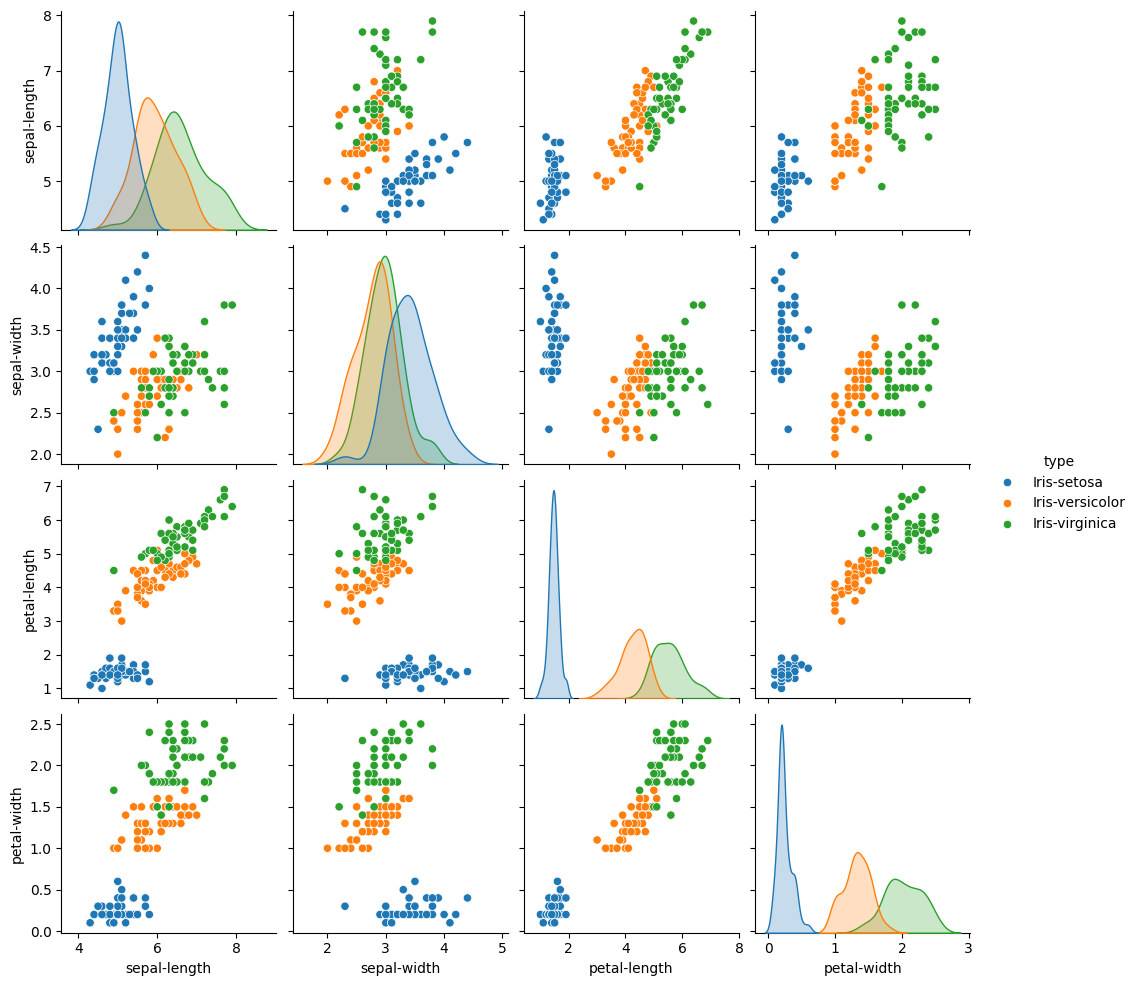

In [14]:
#correlogram. https://seaborn.pydata.org/generated/seaborn.pairplot.html#seaborn.pairplot
sns.pairplot(df, hue='type')
plt.show()

In [15]:
sns.pairplot(df, hue='type')
plot_with_alt_text('A correlogram (or pairplot) showing a matrix of scatterplots pairing each numeric parameter in the data set.'\
    + 'The paired points within each plot are colored according to type.'\
    + 'The diagonal plots from upper left to bottom right have identically paired parameters. Instead of scatterplot, these plots have three univariate distribution plots -one of each type.'\
    + 'x-axis = sepal-length, sepal-width, petal-length, and petal-width.'\
    + 'y-axis = petal-width, petal-length, sepal-width, and sepal-length.'\
    + 'Ranges of individual plots are set to the min and max of the respective parameters.'\
    + 'For each scatterplot a generally positive linear relation can be observed except for petal and sepal pairings of Iris-setosa'\
    + 'For all plots, clustering by type can be seen with Iris-versicolor and Iris-virginica being close together and Iris-setosa being most distinct.'\
    + 'Except the sepal-width distribution where each type is similarly distributed and the sepal-length and sepal-width scatterplot where Iris-versicolor and virginica largely overlap.') 

Each image is a descriptive method *and* a visualization ($\geq3$ meets the requirements). And here are some non-visual descriptions of the data:

In [16]:
df.describe(include='all')

,sepal-length,sepal-width,petal-length,petal-width,type
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,Iris-setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.054000,3.758667,1.198667,NaN
std,0.828066,0.433594,1.764420,0.763161,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


Play around -*explore*. 